#                                                       Loan Approval Prediction                                 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("loan_approval_dataset.csv")

In [3]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## Data Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [6]:
pd.set_option('display.float_format','{:.2f}'.format)

In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [8]:
df['loan_id'].count()

np.int64(4269)

In [9]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [10]:
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [11]:
df.columns=df.columns.str.strip()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [13]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [14]:
df['education']=df['education'].str.strip()
df['self_employed']=df['self_employed'].str.strip()
df['loan_status']=df['loan_status'].str.strip()

In [15]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [16]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [17]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

In [18]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [19]:
df['loan_id']=df['loan_id'].astype(str)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


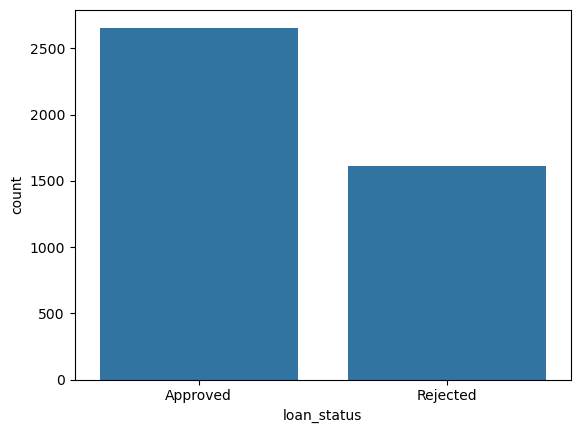

In [21]:
#data balanced or not (seaborn)
sns.countplot(x='loan_status',data=df)
plt.show()
#inbalanced

## Exploratory Data Analysis (EDA)

### 1. self_employement effect on loan?

In [22]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [23]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [24]:
emp_status=df.groupby(['self_employed','loan_status'])['loan_status'].count().unstack()
emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [25]:
emp_status['Total']=emp_status['Approved']+emp_status['Rejected']
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


In [26]:
emp_status['Approval_%']=emp_status['Approved']/emp_status['Total']*100

In [27]:
emp_status

loan_status,Approved,Rejected,Total,Approval_%
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


In [28]:
emp_status['Rejected_%']=emp_status['Rejected']/emp_status['Total']*100
emp_status

loan_status,Approved,Rejected,Total,Approval_%,Rejected_%
self_employed,,,,,
No,1318,801,2119,62.20,37.80
Yes,1338,812,2150,62.23,37.77


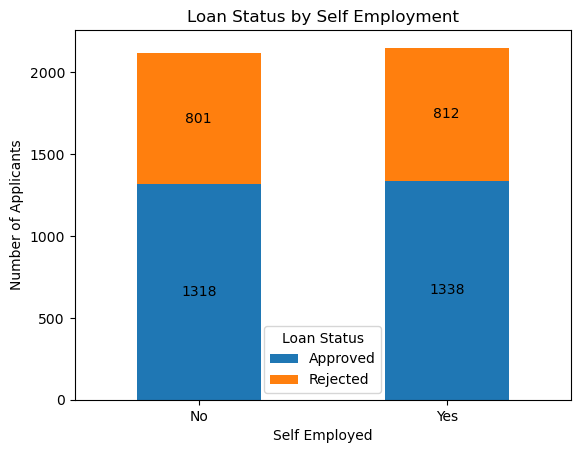

In [29]:
#plot stacked bar chart
#ax-matplotlib axes obj(chart area)
ax=emp_status[['Approved','Rejected']].plot(kind='bar',stacked=True)

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax.containers:
    ax.bar_label(container,label_type='center')

plt.show()

### 2.Education on loan approval

In [30]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [31]:
edu_status=df.groupby(['education','loan_status'])['loan_status'].count().unstack()
edu_status['Total']=edu_status['Approved']+edu_status['Rejected']
edu_status['Approved_%']=edu_status['Approved']/edu_status['Total']*100
edu_status

loan_status,Approved,Rejected,Total,Approved_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


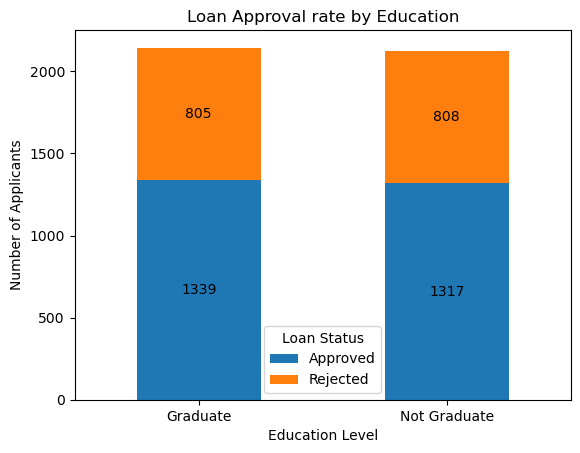

In [32]:
#plot stackked bar chart
ax1=edu_status[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.title("Loan Approval rate by Education")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
for container in ax1.containers:
    ax1.bar_label(container,label_type='center')
plt.show()

### 3.Dependents effect on loan

In [33]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [34]:
deep_status=df.groupby(['no_of_dependents','loan_status'])['loan_status'].count().unstack()
deep_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [35]:
deep_status['Total']=deep_status['Approved']+deep_status['Rejected']
deep_status['Approval_%']=deep_status['Approved']/deep_status['Total']*100
deep_status

loan_status,Approved,Rejected,Total,Approval_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


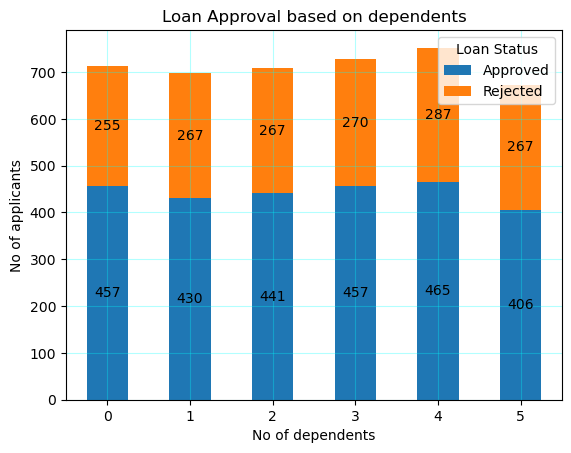

In [36]:
#plot stacked bar chart
ax2=deep_status[['Approved','Rejected']].plot(kind='bar',stacked=True)

plt.title("Loan Approval based on dependents")
plt.xlabel("No of dependents")
plt.ylabel("No of applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.grid(True,color='cyan',alpha=0.3)

for container in ax2.containers:
    ax2.bar_label(container,label_type='center')

plt.show()
#aprroval rate dec with inc in dependents.

### 4.Income and loan_status relation

In [37]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [38]:
df['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [39]:
x=df.groupby(by=['loan_status']).mean(numeric_only=True) ['income_annum']
x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

In [40]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

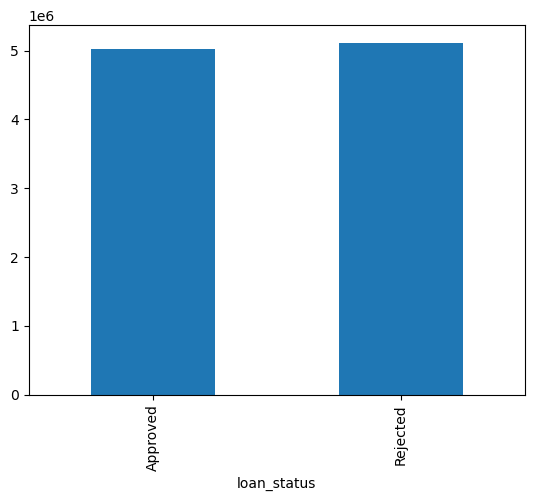

In [41]:
#as x is series
x.plot(kind='bar')

### 5.How does loan amount vary bw approved and rejected loans

In [42]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [43]:
df['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [44]:
y=df.groupby('loan_status').mean(numeric_only=True)['loan_amount']
y

loan_status
Approved   15247251.51
Rejected   14946063.24
Name: loan_amount, dtype: float64

In [45]:
approved_amount=df[df['loan_status']=='Approved']['loan_amount']
approved_amount

0       29900000
6       33000000
8        2200000
10      11200000
13      31500000
          ...   
4261     7500000
4263    12700000
4265    11300000
4267    12800000
4268    29700000
Name: loan_amount, Length: 2656, dtype: int64

In [46]:
rej_amount=df[df['loan_status']=='Rejected']['loan_amount']
rej_amount

1       12200000
2       29700000
3       30700000
4       24200000
5       13500000
          ...   
4258    22600000
4259    11500000
4262     3000000
4264     2300000
4266    23900000
Name: loan_amount, Length: 1613, dtype: int64

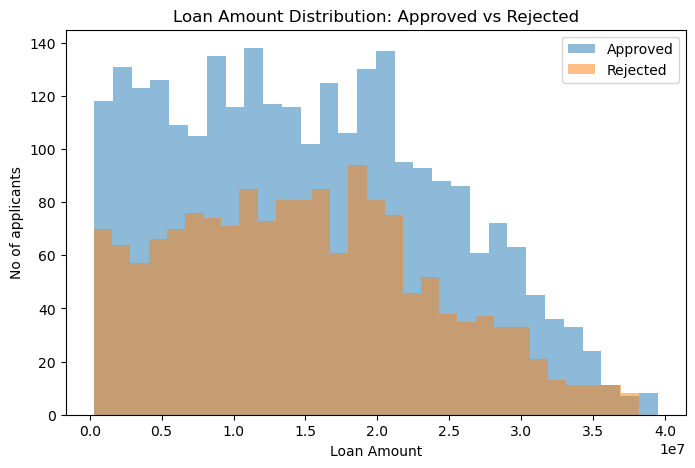

In [47]:
#plot histogram
plt.figure(figsize=(8,5))
plt.hist(approved_amount,bins=30,alpha=0.5,label='Approved')
plt.hist(rej_amount,bins=30,alpha=0.5,label='Rejected')

plt.title("Loan Amount Distribution: Approved vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("No of applicants")
plt.legend()

plt.show()

#approval loans are more concentrated around moderate loan amounts

### 6.Does cibil score strongly influence loan approval?

In [48]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [49]:
df['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [50]:
df.groupby('loan_status')['cibil_score'].mean(numeric_only=True)

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [51]:
#separate loan amounts|
approved_cibil=df[df['loan_status']=='Approved']['cibil_score']
rej_cibil=df[df['loan_status']=='Rejected']['cibil_score']

In [52]:
approved_cibil

0       778
6       678
8       782
10      547
13      679
       ... 
4261    881
4263    865
4265    559
4267    780
4268    607
Name: cibil_score, Length: 2656, dtype: int64

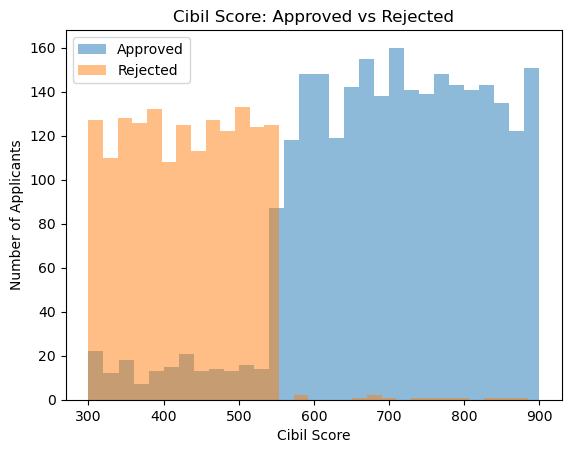

In [53]:
#plot histogram
plt.hist(approved_cibil,bins=30,alpha=0.5,label='Approved')
plt.hist(rej_cibil,bins=30,alpha=0.5,label='Rejected')

plt.title("Cibil Score: Approved vs Rejected")
plt.xlabel("Cibil Score")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

#cibil score low-rejected,cibil score high-approved

## Data visualization

### A.Compare income vs loan amount(scatter plot)

In [54]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


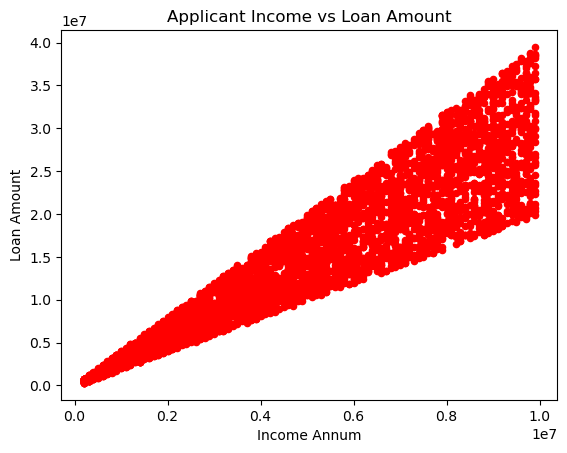

In [55]:
df.plot(x='income_annum',y='loan_amount',kind='scatter',color='red')
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Income Annum")
plt.ylabel("Loan Amount")
plt.show()

#positive correlation inbetween them.

### B.Show Correlation heatmap of numerical features

In [56]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


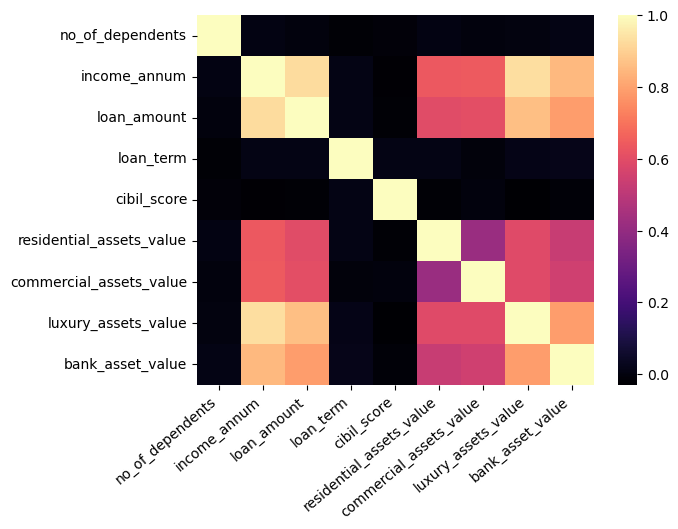

In [57]:
sns.heatmap(df.corr(numeric_only=True),cmap='magma')

plt.xticks(rotation=40,ha='right')
plt.show()

In [58]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.927469910987149)

In [59]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522588)

## Data Cleaning and Feature Engineering

### Detect outliers

In [60]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


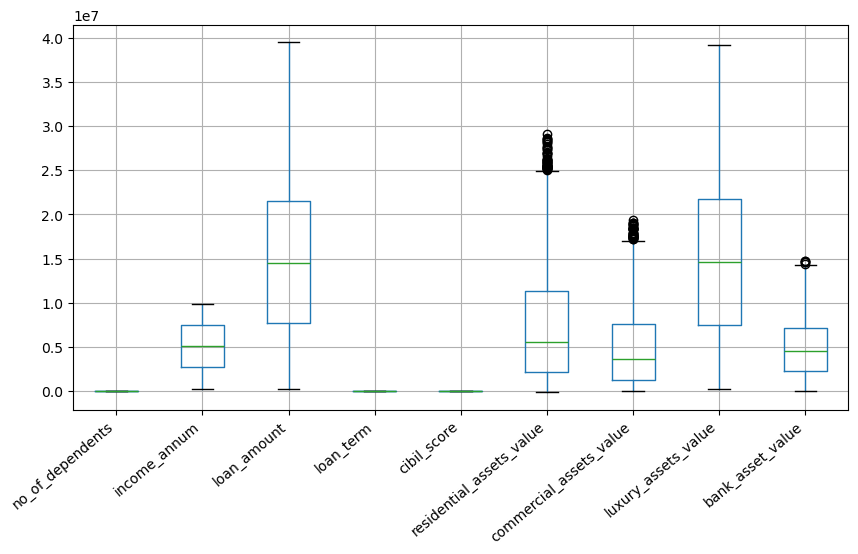

In [61]:
plt.figure(figsize=(10,5))
df.boxplot() #outliers
plt.xticks(rotation=40,ha='right') #col names 
plt.show()

### Remove outliers

In [62]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [63]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [64]:
#using iqr based capping method,to handle outliers,by this we can preserve the data set size while preventing extreme values from biasing the model
#calculate quantile

r_q1=df['residential_assets_value'].quantile(0.25)
r_q3=df['residential_assets_value'].quantile(0.75)

#calculate IQR
IQR=r_q3-r_q1

#Most normal data lies in middle area. Anything too far away is pulled back into acceptable range

In [65]:
IQR

np.float64(9100000.0)

In [66]:
lower_limit=r_q1-1.5*IQR
upper_limit=r_q3+1.5*IQR

In [67]:
df=df[(df['residential_assets_value']>=lower_limit) & (df['residential_assets_value']<=upper_limit)]

In [68]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


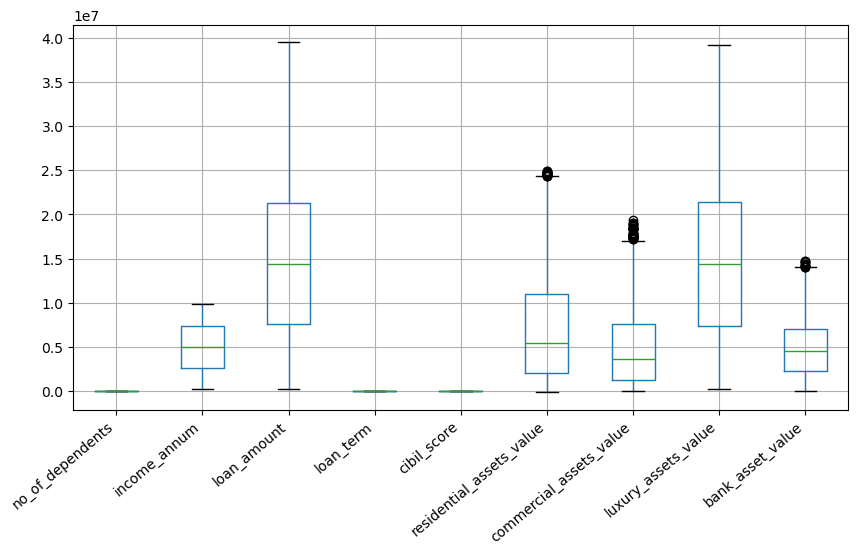

In [69]:
plt.figure(figsize=(10,5))
df.boxplot()
plt.xticks(rotation=40,ha='right')
plt.show()

In [70]:
#for next col
c_q1=df['commercial_assets_value'].quantile(0.25)
c_q3=df['commercial_assets_value'].quantile(0.75)

C_IQR=c_q3-c_q1

l_l=c_q1-1.5*C_IQR
u_l=c_q3+1.58*C_IQR

df=df[(df['commercial_assets_value']>=l_l) & (df['commercial_assets_value']<=u_l)]
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


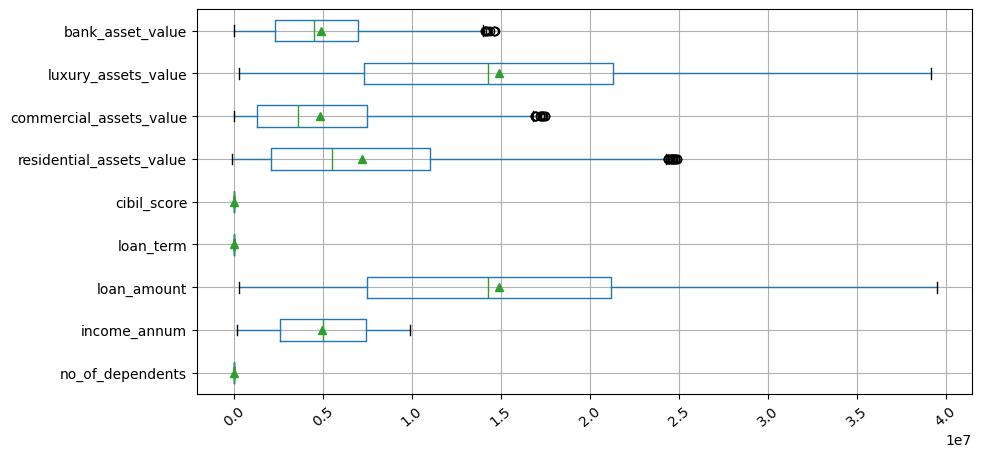

In [71]:
plt.figure(figsize=(10,5))
df.boxplot(showmeans=True,vert=False)
plt.xticks(rotation=40)
plt.show()


### Features to drop

In [72]:
df=df.drop('loan_id',axis=1)

In [73]:
# df.drop['loan_id',axis=1]
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [74]:

df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


### Converting catagorical values into numerical values

### 1.Mapping

In [75]:
df['loan_status']=df['loan_status'].map({'Approved':1,'Rejected':0})

In [76]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


### 2.Encoding

In [77]:
#encode binary col

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['self_employed']=le.fit_transform(df['self_employed'])
                                     

In [78]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


### 3.one-hot encoding

In [79]:
df=pd.get_dummies(df,columns=['education'],dtype=int)
#avoid dummy var trap and keeps model clean

In [80]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,0
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,0,1
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,0,1
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,1


## Model Building

In [83]:
#split features and target
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [84]:
#train - test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [85]:
# build random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=39)


In [86]:
rf_model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
#make prediction

y_pred=rf_model.predict(X_test)


In [88]:
#evaluate the model

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy :",accuracy_score(y_test,y_pred)*100,"%")
print("Classification Report :",classification_report(y_test,y_pred))
print("Confusion Matrix :",confusion_matrix(y_test,y_pred))

Accuracy : 97.85202863961814 %
Classification Report :               precision    recall  f1-score   support

           0       0.98      0.96      0.97       316
           1       0.98      0.99      0.98       522

    accuracy                           0.98       838
   macro avg       0.98      0.98      0.98       838
weighted avg       0.98      0.98      0.98       838

Confusion Matrix : [[304  12]
 [  6 516]]


In [89]:
#feature importance

feature_imp=pd.Series(rf_model.feature_importances_, index=X.columns ).sort_values(ascending=False)

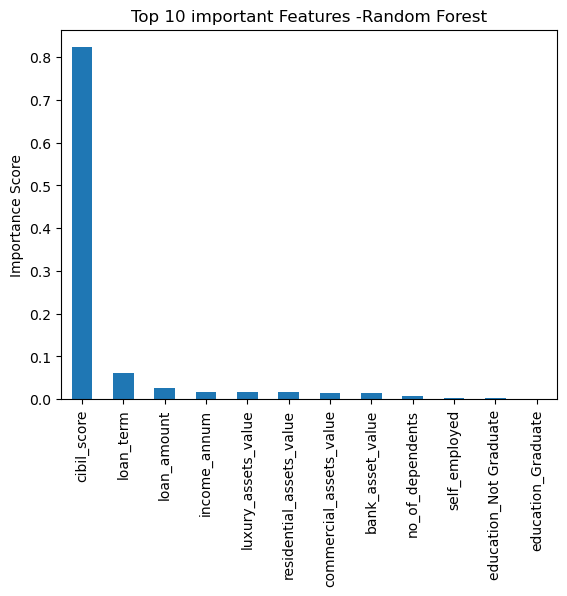

In [90]:
import matplotlib.pyplot as plt

feature_imp.plot(kind='bar')
plt.title("Top 10 important Features -Random Forest")
plt.ylabel("Importance Score")
plt.show()

## Model Prediction

In [91]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,1,0


In [92]:
#  new customer

new_applicant = {
    'no_of_dependents': 4,
    'self_employed': 1,
    'income_annum': 600000,
    'loan_amount': 2500000,
    'loan_term': 36,
    'cibil_score': 900,
    'residential_assets_value': 300000,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 5000,
    'education_Graduate': 1,
    'education_Not Graduate': 1
}

new_df=pd.DataFrame([new_applicant])

In [93]:
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,4,1,600000,2500000,36,900,300000,0,0,5000,1,1


In [94]:
predictions=rf_model.predict(new_df)

In [95]:
predictions

array([1])

## Save Model

In [96]:
import joblib
joblib.dump(rf_model,'loan_approval_prediction.pkl')

['loan_approval_prediction.pkl']

In [97]:
#loading and future pred
loaded_model=joblib.load("loan_approval_prediction.pkl")
#loaded_model.predict(x_test)

In [98]:
loaded_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Accuracy with other models

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X=df.drop('loan_status',axis=1)
y=df['loan_status']


X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=39)

models={
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier()
}

for name,model in models.items():
    model.fit(X_train,y_train)
    preds=model.predict(X_test)
    print(name,"Accuracy",accuracy_score(y_test,preds))

Logistic Regression Accuracy 0.7923627684964201
Decision Tree Accuracy 0.9749403341288783
Random Forest Accuracy 0.9809069212410502
